# 数据切分对比实验 · 你的模型到底有多可信？

## 要回答的问题

> 同一个模型、同一批分子，只改变**切分方式**，性能能差多少？
> 如果差很多，那么平时报的那个分数，到底代表什么？

## 为什么这件事最重要

在 AIDD 里，**怎么切数据比用什么模型更能决定你看到的分数**。
一个用随机切分跑出 R²=0.85 的模型，放到真实的「全新骨架分子」上可能连 0.3 都没有。
这个 notebook 就是用你自己 GHSR1a 的数据，把这件事变成看得见的数字。

## 实验设计

| 项目 | 设定 |
|---|---|
| 数据 | GHSR1a 小分子子集，n = 889 |
| 特征 | Morgan 指纹（radius=2, 2048 bit） |
| 模型 | RandomForest（300 棵） |
| 任务 | 回归预测 pAffinity |
| 切分 | 随机 / Scaffold / Butina（4 档 cutoff） |
| 指标 | R²、MAE、RMSE、Spearman ρ |
| 重复 | 5 个随机种子 |

**关键创新**：除了常规指标，还计算「测试集分子与训练集的最大相似度」——
这个数字直接告诉你：**测试集里的分子，对模型来说有多新。**
没有它，你无法解释分数为什么变。

In [ ]:
# ── 路径初始化 ──────────────────────────────────────────────
# 自动定位项目根目录，使 notebook 在仓库内任意位置都能正确读写。
# 找不到时回退到当前工作目录（兼容扁平用法，如直接放在 ~/aidd 下运行）。
from pathlib import Path
import os


def _find_project_root():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / 'data' / 'processed').is_dir() and (p / 'notebooks').is_dir():
            return p
    return None


_ROOT = _find_project_root()

if _ROOT is not None:
    DATA_DIR = _ROOT / 'data' / 'processed'   # 清洗后的建模数据
    RAW_DIR = _ROOT / 'data' / 'raw'          # 原始数据（不入库，可重新下载）
    FIG_DIR = _ROOT / 'results' / 'figures'   # 图表输出
    for _d in (DATA_DIR, RAW_DIR, FIG_DIR):
        _d.mkdir(parents=True, exist_ok=True)
    print(f'项目根目录: {_ROOT}')
    print(f'  数据 → {DATA_DIR.relative_to(_ROOT)}')
    print(f'  图表 → {FIG_DIR.relative_to(_ROOT)}')
else:
    DATA_DIR = RAW_DIR = FIG_DIR = Path.cwd()
    print('未定位到项目根目录，使用当前工作目录（扁平模式）')


In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
from collections import defaultdict

from rdkit import Chem, RDLogger, DataStructs
from rdkit.Chem import rdFingerprintGenerator
from rdkit.ML.Cluster import Butina
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

RDLogger.DisableLog('rdApp.*')
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Heiti TC']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110

SEEDS = [0, 1, 2, 3, 4]      # 5 个随机种子取平均
N_TREES = 300
FRAC_TRAIN = 0.8
BUTINA_CUTOFFS = [0.35, 0.45, 0.55, 0.65]

print('参数就绪')

参数就绪


## 1. 载入数据并计算指纹

用**小分子子集**——肽类的分子量与柔性会和真实建模目标不一致，
混进来会让模型去学「大分子 vs 小分子」而不是构效关系。

In [2]:
df = pd.read_csv(DATA_DIR / 'ghsr1a_binding_clean.csv')
df = df[~df['peptide_like']].reset_index(drop=True)
df['mol'] = df['canonical_smiles'].apply(Chem.MolFromSmiles)
df = df[df['mol'].notna()].reset_index(drop=True)
n = len(df)

gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fps_list = [gen.GetFingerprint(m) for m in df['mol']]
X = np.array([f.ToList() for f in fps_list], dtype=np.float32)
y = df['pAffinity'].values

print(f'样本数 {n}    特征维度 {X.shape[1]}')
print(f'pAffinity: 均值 {y.mean():.2f}  标准差 {y.std():.2f}  范围 {y.min():.2f}-{y.max():.2f}')

样本数 889    特征维度 2048
pAffinity: 均值 7.33  标准差 1.12  范围 4.30-11.00


In [3]:
# 预计算相似度矩阵（Butina 各档 cutoff 共用，只需算一次）
print(f'计算 {n*(n-1)//2} 个分子对的相似度 ...')
dists = []
for i in range(n):
    s = DataStructs.BulkTanimotoSimilarity(fps_list[i], fps_list[:i])
    dists.extend([1 - x for x in s])
print('完成')

计算 394716 个分子对的相似度 ...
完成


## 2. 三种切分策略

**随机切分**　完全随机打乱。同骨架分子会同时出现在训练集和测试集里，
模型只要"记住"这个骨架的活性就能拿高分——这是**最乐观、最不真实**的场景。

**Scaffold Split**　按 Bemis-Murcko 骨架分组，同一个骨架绝不跨集。
模拟「来了个新骨架」的情况。

**Butina 聚类切分**　按整个分子的指纹相似度做球状聚类，整簇不跨集。
比 scaffold 更严格——它管的不只是骨架，还包括侧链。cutoff 越大越狠。

In [4]:
def random_split(frac=0.8, seed=0):
    rng = np.random.RandomState(seed)
    idx = rng.permutation(n)
    k = int(n * frac)
    return idx[:k], idx[k:]


def group_split(groups, frac=0.8, seed=0):
    """把整个组（骨架簇 or 相似簇）不拆分地分进 train / test。
    大组优先填满训练集，保证测试集是完整的新系列。"""
    rng = np.random.RandomState(seed)
    gs = list(groups)
    rng.shuffle(gs)                 # 同大小的组随机打破平局
    gs.sort(key=len, reverse=True)  # 大组优先进训练集
    n_train = int(n * frac)
    tr, te = [], []
    for g in gs:
        if len(tr) + len(g) <= n_train:
            tr.extend(g)
        else:
            te.extend(g)
    return np.array(tr), np.array(te)


def butina_clusters(cutoff):
    return Butina.ClusterData(dists, n, cutoff, isDistData=True)


scaf_groups = defaultdict(list)
for i, s in enumerate(df['scaffold'].values):
    scaf_groups[s].append(i)

print('切分函数就绪')

切分函数就绪


## 3. 关键诊断指标：测试集到底有多"新"

**这是整个 notebook 的灵魂。**

对每个测试集分子，算它与**所有训练集分子**的最大 Tanimoto 相似度，再取中位数。
这个值越接近 1，说明测试分子在训练集里到处是"亲戚"，模型等于开卷考试；
越接近 0，说明是真正的陌生分子。

**没有这个数字，你看到的 R² 就只是一个孤零零的分数，无法解释。**

In [5]:
def max_sim_to_train(te, tr):
    T, R = X[te], X[tr]
    out = []
    for i in range(0, len(T), 128):
        b = T[i:i + 128]
        inter = b @ R.T
        union = b.sum(1, keepdims=True) + R.sum(1, keepdims=True).T - inter
        out.append(np.where(union > 0, inter / union, 0).max(axis=1))
    return np.concatenate(out)

In [6]:
def run_split(tr, te, seed):
    m = RandomForestRegressor(n_estimators=N_TREES, random_state=seed, n_jobs=-1)
    m.fit(X[tr], y[tr])
    p = m.predict(X[te])
    return dict(r2=r2_score(y[te], p),
                mae=mean_absolute_error(y[te], p),
                rmse=np.sqrt(mean_squared_error(y[te], p)),
                rho=spearmanr(y[te], p).correlation,
                sim=np.median(max_sim_to_train(te, tr)))


def eval_split(getter, label, scenario):
    r = pd.DataFrame([run_split(*getter(s), seed=s) for s in SEEDS])
    return dict(切分方式=label, 对应场景=scenario,
                R2=r['r2'].mean(), R2波动=r['r2'].std(),
                MAE=r['mae'].mean(), Spearman=r['rho'].mean(),
                与训练集相似度=r['sim'].mean())

print('评估函数就绪')

评估函数就绪


## 4. 跑实验

In [7]:
results = []
results.append(eval_split(
    lambda s: random_split(seed=s),
    '随机切分', '同系列补测数据（过度乐观）'))
results.append(eval_split(
    lambda s: group_split(scaf_groups.values(), seed=s),
    'Scaffold Split', '新骨架、同化学类型'))

for cutoff in BUTINA_CUTOFFS:
    cl = butina_clusters(cutoff)
    results.append(eval_split(
        lambda s, cl=cl: group_split(cl, seed=s),
        f'Butina {cutoff:.2f}',
        '新化学系列' if cutoff <= 0.45 else '跨化学类型（不现实）'))

R = pd.DataFrame(results)

# 基线：永远预测训练集均值
BASELINE_MAE = np.abs(y - y.mean()).mean()
print(f'基线（永远预测均值）MAE = {BASELINE_MAE:.3f}   高于此值即模型无效\n')

show = R[['切分方式', '与训练集相似度', 'R2', 'MAE', 'Spearman', '对应场景']].copy()
show['R2'] = show['R2'].round(3)
show['MAE'] = show['MAE'].round(3)
show['Spearman'] = show['Spearman'].round(3)
show['与训练集相似度'] = show['与训练集相似度'].round(3)
display(show)

基线（永远预测均值）MAE = 0.887   高于此值即模型无效



,切分方式,与训练集相似度,R2,MAE,Spearman,对应场景
0,随机切分,0.838,0.485,0.617,0.680,同系列补测数据（过度乐观）
1,Scaffold Split,0.786,0.399,0.615,0.614,新骨架、同化学类型
2,Butina 0.35,0.679,0.291,0.829,0.492,新化学系列
3,Butina 0.45,0.494,-0.047,0.853,0.309,新化学系列
4,Butina 0.55,0.327,0.125,0.911,0.286,跨化学类型（不现实）
5,Butina 0.65,0.250,0.006,0.939,0.322,跨化学类型（不现实）


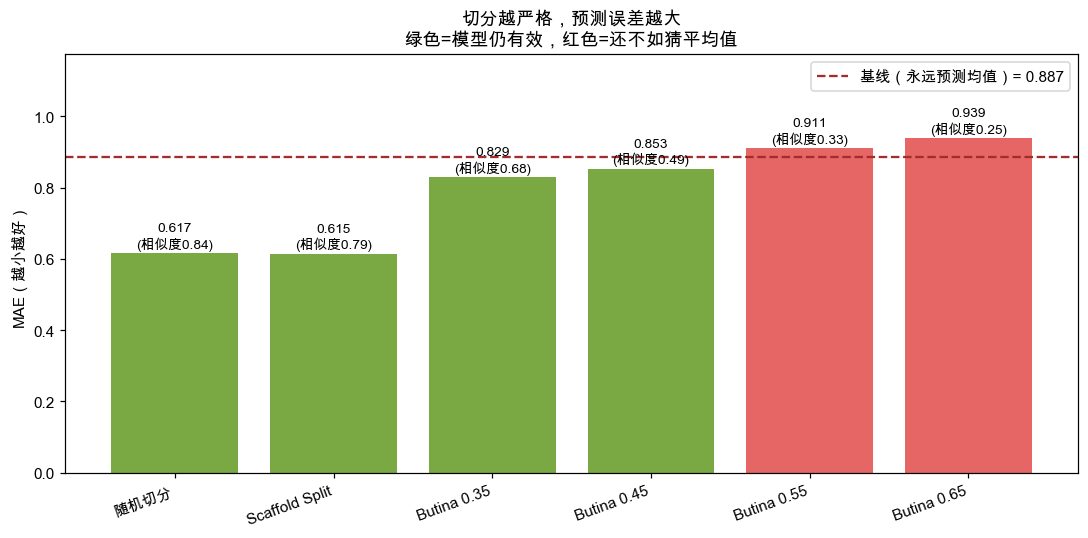

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

labels = R['切分方式'].tolist()
maes = R['MAE'].tolist()
sims = R['与训练集相似度'].tolist()
colors = ['#639922' if m < BASELINE_MAE else '#E24B4A' for m in maes]

bars = ax.bar(range(len(labels)), maes, color=colors, alpha=0.85)
ax.axhline(BASELINE_MAE, color='#A32D2D', linestyle='--', linewidth=1.5,
           label=f'基线（永远预测均值）= {BASELINE_MAE:.3f}')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('MAE（越小越好）')
ax.set_title('切分越严格，预测误差越大\n绿色=模型仍有效，红色=还不如猜平均值')

for i, (b, s) in enumerate(zip(bars, sims)):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.015,
            f'{b.get_height():.3f}\n(相似度{s:.2f})', ha='center', fontsize=9)

ax.legend()
ax.set_ylim(0, max(maes) * 1.25)
plt.tight_layout()
plt.savefig(FIG_DIR / 'split_comparison_mae.png', dpi=150)
plt.show()

## 5. 分层诊断：模型在多"新"的分子上开始失效

前面的对比是"整包"的。更精细的做法是：
**把所有测试分子按它与训练集的最大相似度分箱，看每一箱的误差。**

这样能直接读出一条临界线——超过它，模型就不可信了。

下面用 10 次不同的随机切分累计样本，让每个箱都有足够的分子数。

In [10]:
rows = []
for s in range(10):
    idx = np.random.RandomState(100 + s).permutation(n)
    k = int(n * 0.8)
    tr, te = idx[:k], idx[k:]
    m = RandomForestRegressor(n_estimators=N_TREES, random_state=s, n_jobs=-1)
    m.fit(X[tr], y[tr])
    p = m.predict(X[te])
    rows.append(pd.DataFrame({'sim': max_sim_to_train(te, tr),
                              'err': np.abs(y[te] - p)}))
D = pd.concat(rows, ignore_index=True)
print(f'累计测试分子 {len(D)} 个')

累计测试分子 1780 个


In [11]:
bins = [(0.0, 0.5, '基本无关'), (0.5, 0.6, '远亲'),
        (0.6, 0.7, '同一化学系列'), (0.7, 0.85, '近亲'), (0.85, 1.01, '高度相似')]

print(f"  {'相似度区间':<16}{'分子数':>8}{'占比':>8}{'MAE':>8}   判读")
print('  ' + '-' * 58)
plot_rows = []
for lo, hi, note in bins:
    sub = D[(D['sim'] >= lo) & (D['sim'] < hi)]
    if len(sub) == 0:
        continue
    mae = sub['err'].mean()
    verdict = '模型失效' if mae > BASELINE_MAE else ('勉强' if mae > BASELINE_MAE * 0.85 else '可靠')
    print(f'  {lo:.2f}–{min(hi,1.0):.2f}{"":<6}{len(sub):>8}'
          f'{len(sub)/len(D)*100:>7.1f}%{mae:>8.3f}   {note} · {verdict}')
    plot_rows.append((f'{lo:.2f}–{min(hi,1.0):.2f}', mae, note))

  相似度区间                分子数      占比     MAE   判读
  ----------------------------------------------------------
  0.00–0.50            25    1.4%   1.036   基本无关 · 模型失效
  0.50–0.60            32    1.8%   0.881   远亲 · 勉强
  0.60–0.70            84    4.7%   0.693   同一化学系列 · 可靠
  0.70–0.85           880   49.4%   0.661   近亲 · 可靠
  0.85–1.00           759   42.6%   0.644   高度相似 · 可靠


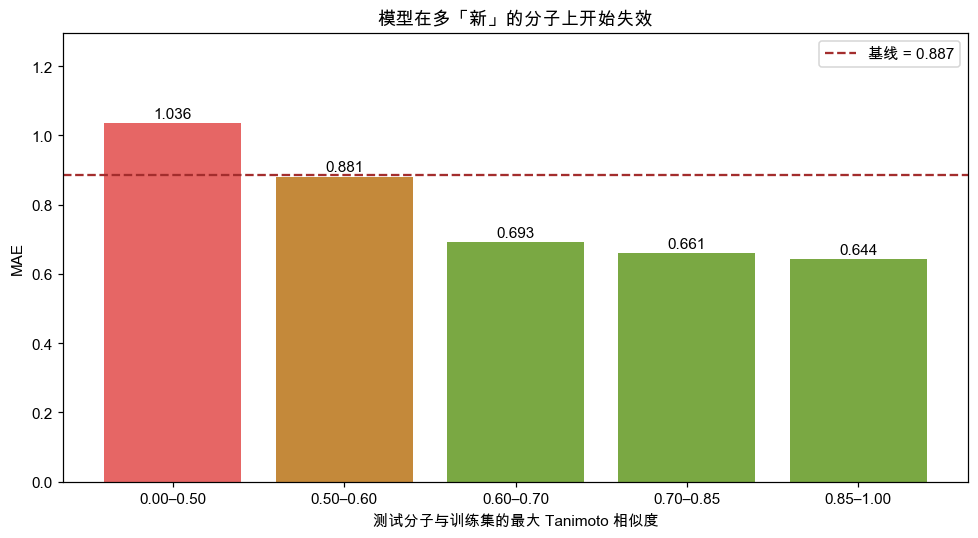

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
names = [p[0] for p in plot_rows]
vals = [p[1] for p in plot_rows]
cols = ['#639922' if v < BASELINE_MAE * 0.95 else ('#BA7517' if v < BASELINE_MAE else '#E24B4A')
        for v in vals]

b = ax.bar(names, vals, color=cols, alpha=0.85)
ax.axhline(BASELINE_MAE, color='#A32D2D', linestyle='--', linewidth=1.5,
           label=f'基线 = {BASELINE_MAE:.3f}')
ax.set_xlabel('测试分子与训练集的最大 Tanimoto 相似度')
ax.set_ylabel('MAE')
ax.set_title('模型在多「新」的分子上开始失效')

for r, v in zip(b, vals):
    ax.text(r.get_x() + r.get_width() / 2, v + 0.015, f'{v:.3f}', ha='center', fontsize=10)

ax.legend()
ax.set_ylim(0, max(vals) * 1.25)
plt.tight_layout()
plt.savefig(FIG_DIR / 'novelty_vs_error.png', dpi=150)
plt.show()

## 6. 怎么读这些结果

### 三个层次

**第一层 · 分数会骗人**
随机切分与最严格切分之间，R² 可以从 0.485 掉到负数，MAE 涨 50% 以上。
**同一个模型、同一批数据**，只改切分方式就有这个差距——
所以任何不说明切分方式的性能报告，都不可信。

**第二层 · Scaffold Split 不是万能的**
在你的数据上，随机切分 → Scaffold Split 的差距**意外地小**
（MAE 0.617 → 0.615，几乎没变）。

原因是**你的数据集骨架碎片化严重**：889 个分子、385 种骨架，
平均每个骨架只有 2.3 个分子。同骨架分子本来就少，
随机切分时它们也难有机会同时落进训练集和测试集，
所以 scaffold split 的"惩罚"被稀释了。

**这是一个反直觉但很重要的教训**：
scaffold split 的严厉程度，取决于你数据的骨架结构。
骨架越集中（每个骨架几十上百个分子），随机切分的水分就越大；
骨架越碎片化，两者差距越小——**但这不代表可以不做，因为你事先不知道。**

**第三层 · 真正的失效临界点**
分层诊断给出了最有用的数字：**相似度低于约 0.6，模型就开始失效**。
高于 0.6 时 MAE 稳定在 0.64–0.69（约 4–5 倍浓度误差，在早期筛选中可接受）；
低于 0.5 时 MAE 超过 1.0，比直接猜平均值还差。

### 实践含义

| 你要做的事 | 该不该信模型 |
|---|---|
| 在一个已知系列里补测、排优先级 | **可以信**（相似度通常 >0.7） |
| 换一个全新的骨架 | **谨慎**（先看相似度，低于 0.6 就别信） |
| 评估一个从未见过的化学类型 | **不能信**，模型必然失效 |

### 记住一句话

> **模型不是"预测活性"，而是"在已知化学空间内插值"。**
> 一旦要求它外推，它就会退化成一个昂贵的平均值猜测器。

### 下一步

- 换更强的模型（XGBoost、图神经网络）能抬高整体水平，
  但**改变不了失效临界点**——这是数据的性质，不是模型的问题
- 想真正解决外推问题，需要引入物理信息（对接打分、FEP）或主动学习
- 把「相似度门槛」做成你建模流程里的一道工序：
  预测新分子时先算它与训练集的最大相似度，低于 0.6 的结果直接标红